# EDA del Dataset

**Objetivo:** Explorar el dataset, analizar calidad de imágenes, distribución de clases y anotaciones antes del entrenamiento con YOLOv8.


## 0. Imports

In [22]:
import os
import sys
import json
import yaml
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image, ImageStat
import cv2
from tqdm import tqdm
from dotenv import load_dotenv

# Estilo de gráficas
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
sns.set_palette("husl")
print("Imports OK")
print(f"Python: {sys.version}")
print(f"OpenCV: {cv2.__version__}")

Imports OK
Python: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
OpenCV: 4.13.0


## 1. Importar Dataset

In [23]:
# Ruta base del dataset
DATASET_PATH = Path("data")
# Verificar que existen las carpetas estándar de YOLOv8
splits = ["train", "valid", "test"]
for split in splits:
    img_dir   = DATASET_PATH / split / "images"
    label_dir = DATASET_PATH / split / "labels"
    n_imgs    = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png"))) if img_dir.exists() else 0
    n_labels  = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0
    print(f"  {split:6s} → {n_imgs:4d} imágenes | {n_labels:4d} labels")

# Leer data.yaml para obtener las clases
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

CLASSES = data_cfg["names"]
NUM_CLASSES = len(CLASSES)
print(f"\n Clases ({NUM_CLASSES}): {CLASSES}")

  train  → 3429 imágenes | 3429 labels
  valid  →  871 imágenes |  871 labels
  test   →  417 imágenes |  417 labels

 Clases (9): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'pores', 'skin redness', 'wrinkle']


## 2. Distribución de Clases

In [24]:
def count_annotations(dataset_path, splits, classes):
    """Cuenta anotaciones por clase y por split."""
    records = []
    for split in splits:
        label_dir = Path(dataset_path) / split / "labels"
        if not label_dir.exists():
            continue
        for label_file in label_dir.glob("*.txt"):
            with open(label_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        records.append({
                            "split": split,
                            "class_id": cls_id,
                            "class_name": classes[cls_id] if cls_id < len(classes) else f"unknown_{cls_id}"
                        })
    return pd.DataFrame(records)

df_annotations = count_annotations(DATASET_PATH, splits, CLASSES)
print(f"Total anotaciones: {len(df_annotations):,}")
print("\nPor clase:")
print(df_annotations["class_name"].value_counts().to_string())

Total anotaciones: 29,275

Por clase:
class_name
acne            22340
wrinkle          2377
dry              2123
oily              950
pores             702
dark circle       513
darkspot          124
skin redness      123
normal skin        23


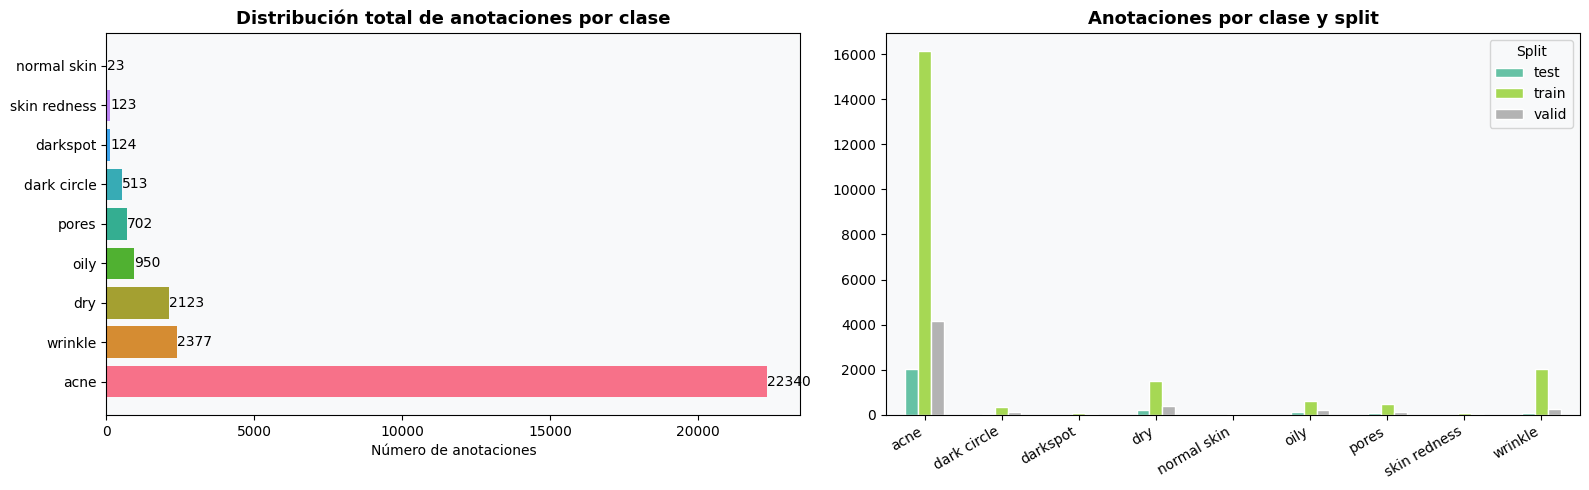

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfica 1: Total por clase ---
class_counts = df_annotations["class_name"].value_counts()
bars = axes[0].barh(class_counts.index, class_counts.values,
                    color=sns.color_palette("husl", len(class_counts)))
axes[0].set_title("Distribución total de anotaciones por clase", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de anotaciones")
for bar, val in zip(bars, class_counts.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)

# --- Gráfica 2: Por clase y split (stacked bar) ---
pivot = df_annotations.groupby(["class_name", "split"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor='white')
axes[1].set_title("Anotaciones por clase y split", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(title="Split")

output_dir = Path("results/reports")
output_dir.mkdir(parents=True, exist_ok=True) 
plt.tight_layout()
plt.savefig(output_dir / "01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()



Las clases se encuentran bastante desbalanceadas, la clase acne domina el dataset, mientras que las clases minoritaras son normal skin, skin redness y darkspot

## 3. Análisis de Imágenes

In [26]:
def analyze_images(dataset_path, splits, sample_size=200):
    """Analiza resolución, brillo y contraste de una muestra de imágenes."""
    records = []
    all_imgs = []
    for split in splits:
        img_dir = Path(dataset_path) / split / "images"
        if img_dir.exists():
            all_imgs += [(f, split) for f in img_dir.glob("*.jpg")]
            all_imgs += [(f, split) for f in img_dir.glob("*.png")]

    sample = random.sample(all_imgs, min(sample_size, len(all_imgs)))

    for img_path, split in tqdm(sample, desc="Analizando imágenes"):
        try:
            img = Image.open(img_path).convert("RGB")
            w, h = img.size
            arr  = np.array(img)
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            records.append({
                "split":     split,
                "filename":  img_path.name,
                "width":     w,
                "height":    h,
                "aspect":    round(w / h, 2),
                "brightness": float(np.mean(gray)),
                "contrast":   float(np.std(gray)),
                "blur":       float(cv2.Laplacian(gray, cv2.CV_64F).var())  # var. laplaciana = nitidez
            })
        except Exception as e:
            print(f"Error en {img_path.name}: {e}")

    return pd.DataFrame(records)

df_imgs = analyze_images(DATASET_PATH, splits)
print(df_imgs.describe().round(2).to_string())

Analizando imágenes: 100%|██████████| 200/200 [00:05<00:00, 33.45it/s]


       width  height  aspect  brightness  contrast     blur
count  200.0   200.0   200.0      200.00    200.00   200.00
mean   640.0   640.0     1.0      135.50     48.00   212.49
std      0.0     0.0     0.0       34.06     14.79   259.22
min    640.0   640.0     1.0       49.55     12.19     5.00
25%    640.0   640.0     1.0      112.71     37.40    47.77
50%    640.0   640.0     1.0      136.21     49.66   129.22
75%    640.0   640.0     1.0      158.27     58.75   243.54
max    640.0   640.0     1.0      217.43     87.70  1427.70


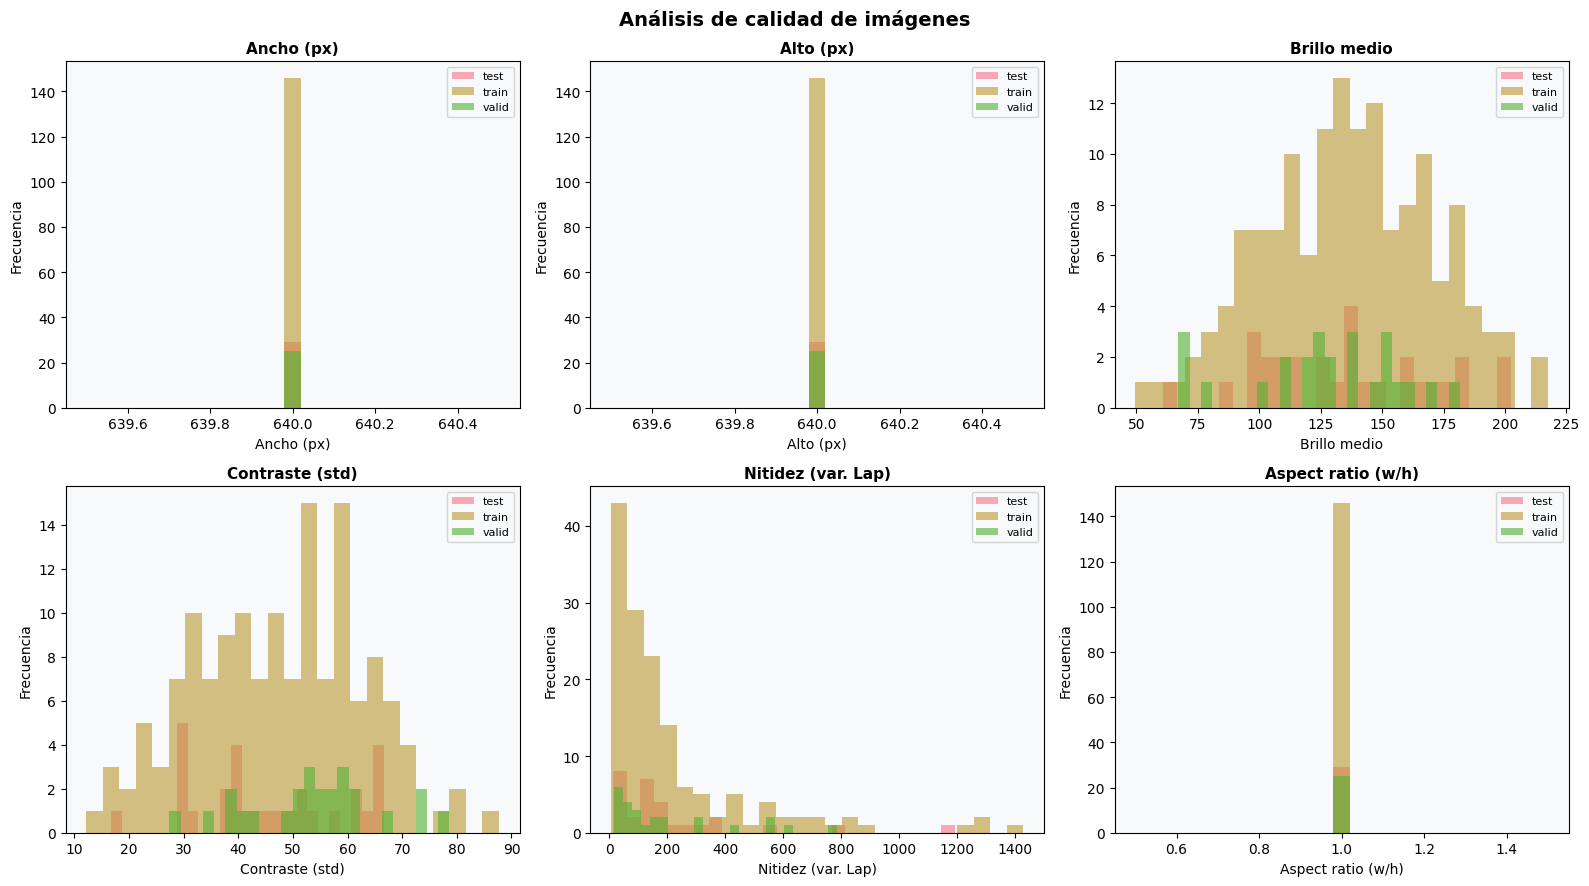

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Análisis de calidad de imágenes", fontsize=14, fontweight='bold')

metrics = [
    ("width",      "Ancho (px)",         axes[0, 0]),
    ("height",     "Alto (px)",          axes[0, 1]),
    ("brightness", "Brillo medio",       axes[0, 2]),
    ("contrast",   "Contraste (std)",    axes[1, 0]),
    ("blur",       "Nitidez (var. Lap)", axes[1, 1]),
    ("aspect",     "Aspect ratio (w/h)", axes[1, 2]),
]

for col, label, ax in metrics:
    for split, grp in df_imgs.groupby("split"):
        ax.hist(grp[col], bins=25, alpha=0.6, label=split)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(output_dir / "02_image_quality.png", dpi=150, bbox_inches='tight')
plt.show()

- las distribuciones de luz y contrasten son homogéneas
- todas las imagenes estan fijadas en un tamaño 640 x 640
- en cuanto a nitidez la mayoria de imagenes están concentradas entre 0 y 200, que implica una nitidez baja

**Resumen de nitidez, brillo y contraste**

In [28]:
# ── Detectar imágenes problemáticas ──────────────────────────────────────────
print("=" * 55)
print("  REPORTE DE CALIDAD")
print("=" * 55)

# 1. Imágenes muy oscuras o muy brillantes
dark   = df_imgs[df_imgs["brightness"] < 50]
bright = df_imgs[df_imgs["brightness"] > 220]
print(f"\n Imágenes muy oscuras  (brillo < 50):   {len(dark):3d}")
print(f" Imágenes muy brillantes (brillo > 220): {len(bright):3d}")

# 2. Bajo contraste
low_contrast = df_imgs[df_imgs["contrast"] < 20]
print(f"Bajo contraste (std < 20):             {len(low_contrast):3d}")

# 3. Imágenes borrosas (nitidez baja = var. Laplaciana < 100)
blurry = df_imgs[df_imgs["blur"] < 100]
print(f" Posiblemente borrosas (nitidez < 100): {len(blurry):3d}")

# 4. Resoluciones no estándar
non_square = df_imgs[df_imgs["aspect"].apply(lambda x: abs(x - 1.0) > 0.3)]
print(f"Aspect ratio muy diferente de 1:1:     {len(non_square):3d}")

# Recomendación: revisar estas imágenes antes de entrenar."
#   El preprocesado las normalizará automáticamente a 640x640."

  REPORTE DE CALIDAD

 Imágenes muy oscuras  (brillo < 50):     1
 Imágenes muy brillantes (brillo > 220):   0
Bajo contraste (std < 20):               6
 Posiblemente borrosas (nitidez < 100):  87
Aspect ratio muy diferente de 1:1:       0


El conjunto de datos ya está bien preparado en términos generales. Todas las imágenes mantienen las proporciones correctas, por lo que no presentan deformaciones ni estiramientos. Además, la calidad de la iluminación es muy buena, ya que solo se identificó una imagen demasiado oscura y ninguna con exceso de luz.

Sin embargo, el análisis muestra que la calidad visual de 87 imágenes podrían estar desenfocadas y 6 con poco contraste. Esto indica que la principal dificultad para el modelo no estará relacionada con la forma o la iluminación de las imágenes, sino con su capacidad para reconocer patrones cuando los detalles, las texturas o los bordes no se observan con suficiente claridad.


## 4. Análisis de Bounding Boxes

In [29]:
def parse_bboxes(dataset_path, splits, classes):
    """
    Lee todos los archivos de labels YOLO y extrae info de los bboxes.
    Formato YOLO: class_id  cx  cy  w  h  (valores normalizados 0-1)
    """
    records = []
    for split in splits:
        label_dir = Path(dataset_path) / split / "labels"
        img_dir   = Path(dataset_path) / split / "images"
        if not label_dir.exists():
            continue
        for lf in label_dir.glob("*.txt"):
            # Intentar leer tamaño real de la imagen
            for ext in [".jpg", ".png", ".jpeg"]:
                img_path = img_dir / (lf.stem + ext)
                if img_path.exists():
                    img = Image.open(img_path)
                    iw, ih = img.size
                    break
            else:
                iw, ih = 640, 640  # fallback

            with open(lf) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                        # Área relativa de la bbox respecto a la imagen
                        area_pct = bw * bh * 100
                        records.append({
                            "split":      split,
                            "class_name": classes[cls_id] if cls_id < len(classes) else f"cls_{cls_id}",
                            "cx": cx, "cy": cy,
                            "bw": bw, "bh": bh,
                            "area_pct": area_pct,
                            "abs_w": bw * iw,
                            "abs_h": bh * ih
                        })
    return pd.DataFrame(records)

df_bboxes = parse_bboxes(DATASET_PATH, splits, CLASSES)
print(f"Total bboxes: {len(df_bboxes):,}")
print("\nTamaño medio por clase (% del área de imagen):")
print(df_bboxes.groupby("class_name")["area_pct"].mean().round(2).sort_values(ascending=False))

Total bboxes: 27,097

Tamaño medio por clase (% del área de imagen):
class_name
normal skin     34.35
darkspot        14.50
skin redness     9.36
oily             8.89
dry              6.68
dark circle      3.15
pores            1.72
acne             1.27
wrinkle          0.35
Name: area_pct, dtype: float64


C:\Users\lesli\AppData\Local\Temp\ipykernel_7720\3620945238.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bboxes, x="class_name", y="area_pct", ax=axes[1], palette="husl")
C:\Users\lesli\AppData\Local\Temp\ipykernel_7720\3620945238.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')


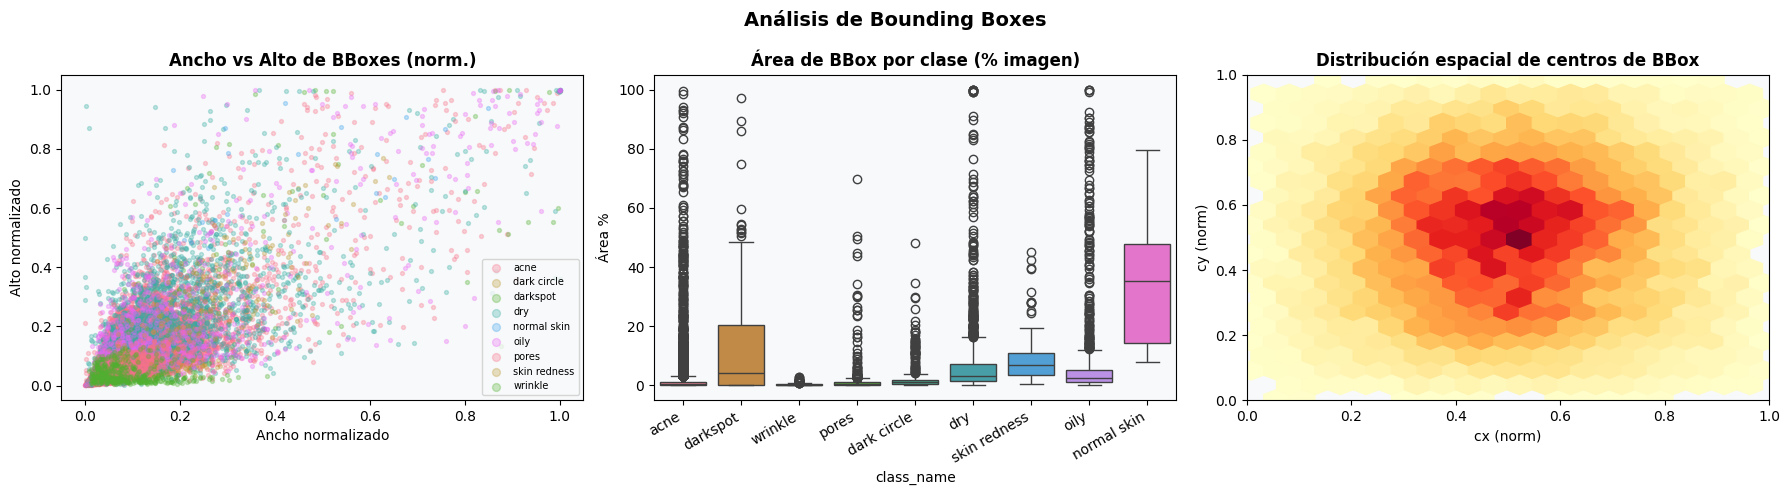


 BBoxes muy pequeñas (área < 0.5% imagen): 13223 (48.8%)
   → Estas lesiones pequeñas pueden necesitar img_size=1280 en el entrenamiento.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Bounding Boxes", fontsize=14, fontweight='bold')

# --- Distribución de tamaños ---
for cls, grp in df_bboxes.groupby("class_name"):
    axes[0].scatter(grp["bw"], grp["bh"], alpha=0.3, s=8, label=cls)
axes[0].set_title("Ancho vs Alto de BBoxes (norm.)", fontweight='bold')
axes[0].set_xlabel("Ancho normalizado")
axes[0].set_ylabel("Alto normalizado")
axes[0].legend(fontsize=7, markerscale=2)

# --- Distribución del área ---
sns.boxplot(data=df_bboxes, x="class_name", y="area_pct", ax=axes[1], palette="husl")
axes[1].set_title("Área de BBox por clase (% imagen)", fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylabel("Área %")

# --- Centro de las BBoxes (heatmap de densidad) ---
axes[2].hexbin(df_bboxes["cx"], df_bboxes["cy"],
               gridsize=20, cmap="YlOrRd", mincnt=1)
axes[2].set_title("Distribución espacial de centros de BBox", fontweight='bold')
axes[2].set_xlabel("cx (norm)")
axes[2].set_ylabel("cy (norm)")
axes[2].invert_yaxis()
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(output_dir / "03_bbox_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# Alerta: bboxes muy pequeñas pueden ser difíciles de detectar
tiny = df_bboxes[df_bboxes["area_pct"] < 0.5]
print(f"\n BBoxes muy pequeñas (área < 0.5% imagen): {len(tiny)} ({100*len(tiny)/len(df_bboxes):.1f}%)")
print("   → Estas lesiones pequeñas pueden necesitar img_size=1280 en el entrenamiento.")

En total, el dataset contiene 27.097 bounding boxes, lo que proporciona una cantidad considerable de ejemplos para el entrenamiento del modelo. Sin embargo, las anotaciones del dataset presentan una gran variabilidad en tamaño, con clases que abarcan regiones muy amplias y otras que corresponden a detalles muy pequeños, las bounding boxes se concentran mayoritariamente en la zona central de las imágenes. Las categorías normal skin (34,35%) y darkspot (14,50%) ocupan, en promedio, una proporción mucho mayor de la imagen, mientras que clases como acne (1,27%) y especialmente wrinkle (0,35%) corresponden a regiones muy pequeñas y localizadas.

el principal desafío para el modelo será detectar correctamente objetos de pequeño tamaño y generalizar a distintas escalas, porque deberá aprender a identificar tanto áreas extensas de la piel como detalles muy pequeños. En consecuencia, es esperable que las clases con bounding boxes de menor tamaño resulten más difíciles de detectar y requieran una mayor precisión para distinguir correctamente sus características visuales, para esto se podria hcer un resize y aumentar a 1280 sin embargo sería más pesado el entrenamiento y tardaria más. esto en viable accediendo a una GPU de buena capacidad, en local no lo podríamos ejecutar ya que tardaría mucho tiempo 

## 5. Visualización de Muestras por Clase

C:\Users\lesli\AppData\Local\Temp\ipykernel_7720\1127411525.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(classes))


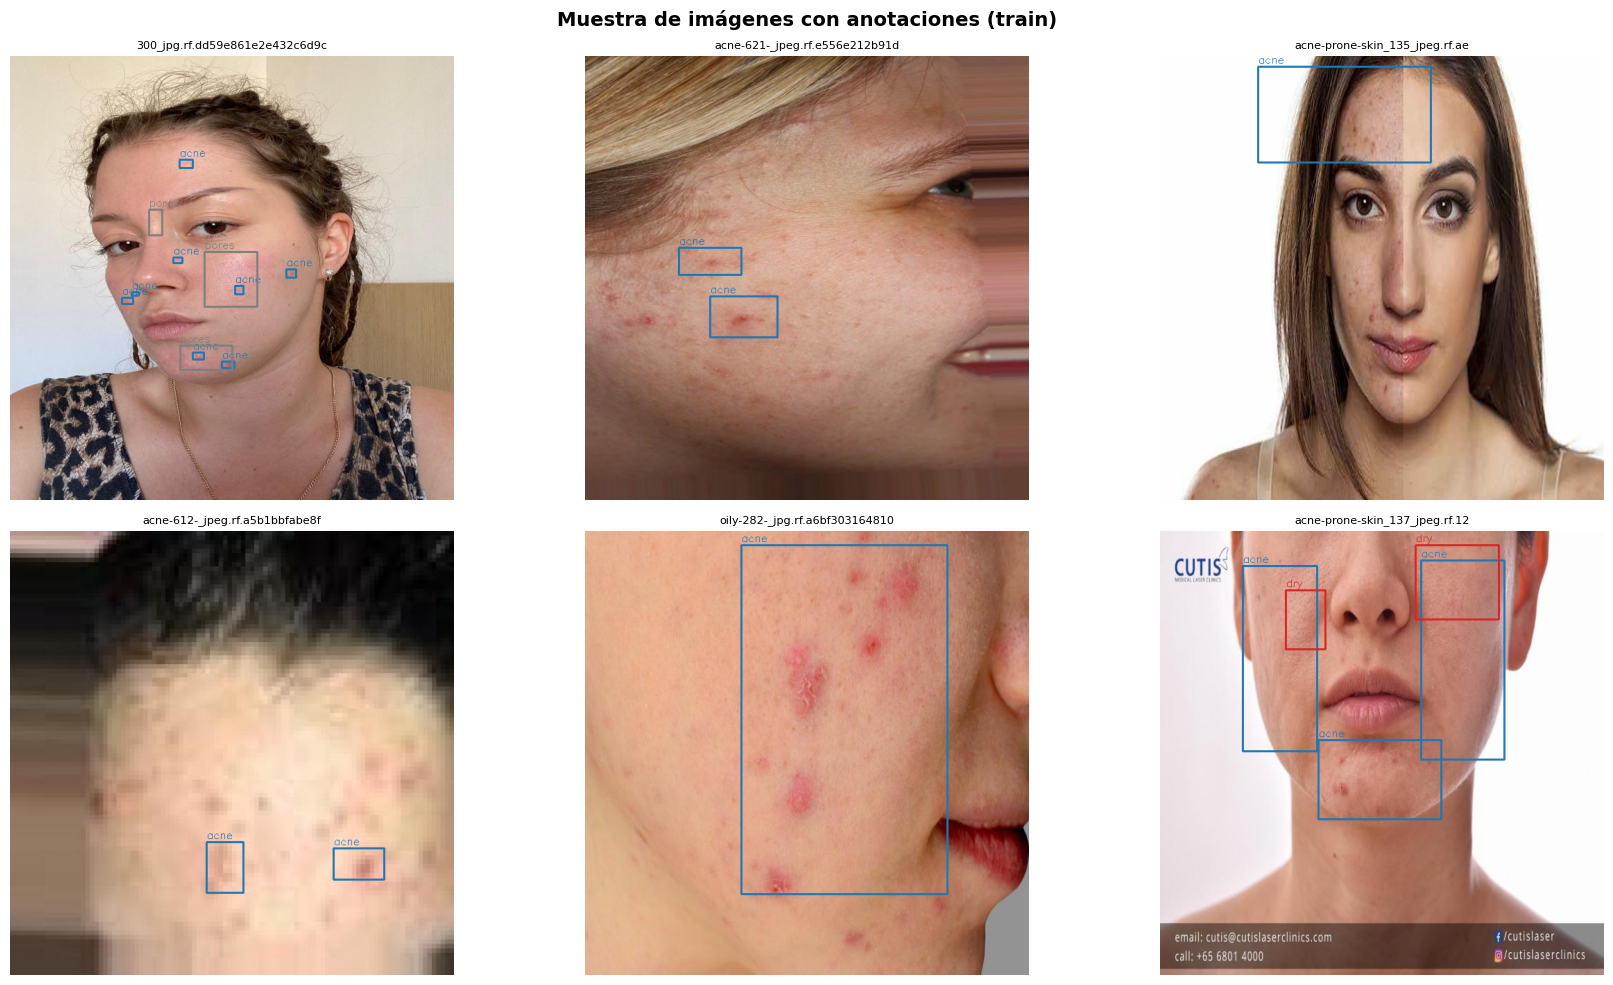

In [31]:
def draw_yolo_boxes(img_path, label_path, classes, conf_scores=None):
    """Dibuja bounding boxes YOLO sobre una imagen."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    colors = plt.cm.get_cmap("tab10", len(classes))

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)

                color = tuple(int(c*255) for c in colors(cls_id)[:3])
                cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
                label = classes[cls_id] if cls_id < len(classes) else str(cls_id)
                cv2.putText(img, label, (x1, max(y1-5, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img

# Mostrar 3 imágenes aleatorias del set de entrenamiento con sus bboxes
train_imgs = list((DATASET_PATH / "train" / "images").glob("*.jpg"))
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Muestra de imágenes con anotaciones (train)", fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flat, sample_imgs):
    label_path = DATASET_PATH / "train" / "labels" / (img_path.stem + ".txt")
    img_drawn = draw_yolo_boxes(img_path, label_path, CLASSES)
    ax.imshow(img_drawn)
    ax.axis("off")
    ax.set_title(img_path.stem[:30], fontsize=8)

plt.tight_layout()
plt.savefig(output_dir / "04_sample_annotated.png", dpi=150, bbox_inches='tight')
plt.show()

Buscando al menos 1 ejemplo por clase...



C:\Users\lesli\AppData\Local\Temp\ipykernel_7720\1127411525.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(classes))


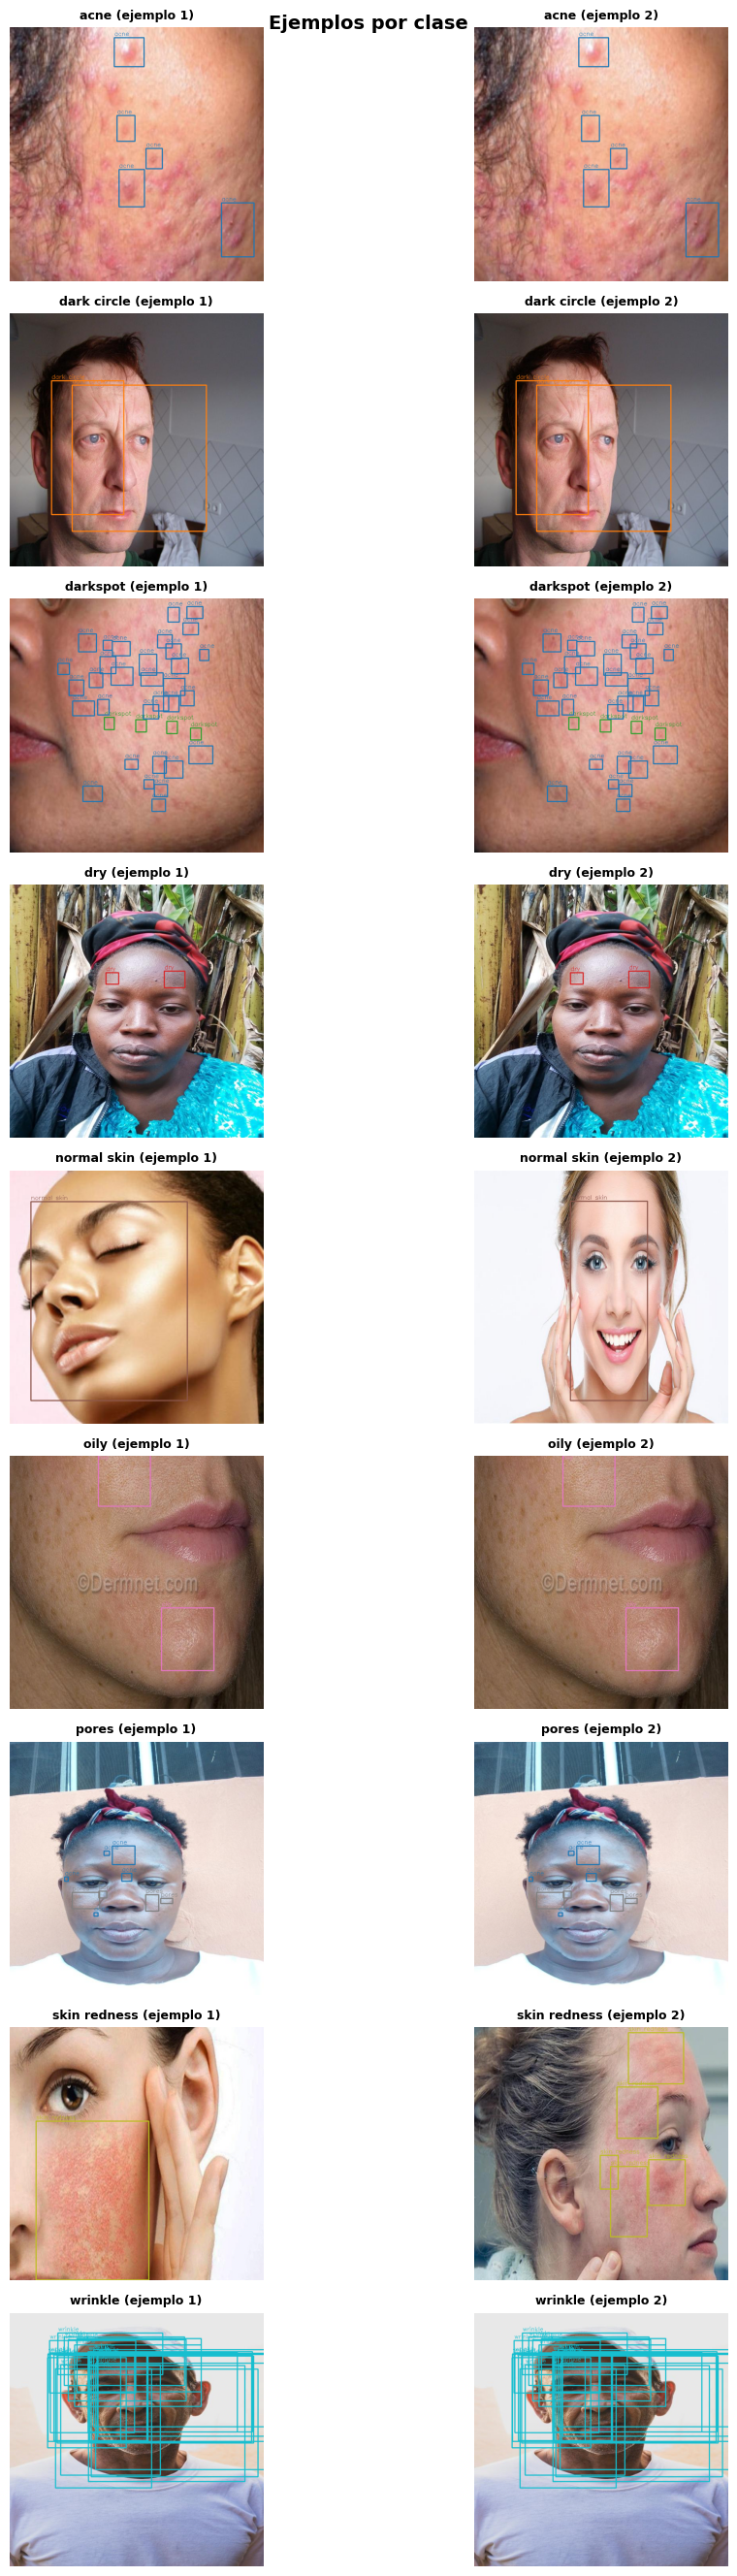

In [32]:
# Mostrar al menos 1 imagen por clase
print("Buscando al menos 1 ejemplo por clase...\n")

class_samples = defaultdict(list)
for split in ["train", "valid"]:
    label_dir = DATASET_PATH / split / "labels"
    img_dir   = DATASET_PATH / split / "images"
    if not label_dir.exists():
        continue
    for lf in label_dir.glob("*.txt"):
        with open(lf) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                cls_name = CLASSES[cls_id] if cls_id < len(CLASSES) else f"cls_{cls_id}"
                for ext in [".jpg", ".png"]:
                    ip = img_dir / (lf.stem + ext)
                    if ip.exists() and len(class_samples[cls_name]) < 2:
                        class_samples[cls_name].append((ip, lf))
                        break

n_classes = len(CLASSES)
fig, axes = plt.subplots(n_classes, 2, figsize=(12, n_classes * 3))
fig.suptitle("Ejemplos por clase", fontsize=14, fontweight='bold')

for row, cls_name in enumerate(CLASSES):
    samples = class_samples.get(cls_name, [])
    for col in range(2):
        ax = axes[row, col] if n_classes > 1 else axes[col]
        if col < len(samples):
            ip, lp = samples[col]
            img_drawn = draw_yolo_boxes(ip, lp, CLASSES)
            ax.imshow(img_drawn)
            ax.set_title(f"{cls_name} (ejemplo {col+1})", fontsize=9, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f"Sin ejemplos\n({cls_name})",
                    ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")

plt.tight_layout()
plt.savefig(output_dir / "05_class_examples.png", dpi=150, bbox_inches='tight')
plt.show()

Se observan imagenes repetidas para el mismo label o clase

## 6. Conclusiones y proximos pasos

- El dataset cuenta 4.717 imágenes y 29.275 anotaciones distribuidas en 9 clases
- El principal hallazgo del análisis es el fuerte desbalance entre clases. La clase acne concentra la gran mayoría de las anotaciones, mientras que clases como normal skin, skin redness y darkspot tienen muy pocos ejemplos. Esta diferencia implica que el modelo podría aprender con mayor facilidad las clases dominantes y presentar un rendimiento inferior en las minoritarias si no se aplican estrategias de compensación, para esto intentaremos agregar imagenes a las clases minoritarias buscando balancear el dataset, haremos data augmentation y usaremos pesos en el entrenamiento para que penalice más los errores de predicción en calses minoritarias.
- Tenemos algunas imagenes borrosas en el dataset que podremos mejorar en el preprocesamiento
